In [1]:
using ThinkJulia

┌ Info: Precompiling ThinkJulia [d92244c1-9090-5a36-a620-f6fb516cc00e]
└ @ Base loading.jl:1186
┌ Info: Precompiling Luxor [ae8d54c2-7ccd-5906-9d76-62fc9837b5bc]
└ @ Base loading.jl:1186
┌ Info: Precompiling TikzPictures [37f6aa50-8035-52d0-81c2-5a1d08754b2d]
└ @ Base loading.jl:1186
┌ Info: Recompiling stale cache file /Users/dsatterthwaite/.julia/compiled/v1.0/Plots/ld3vC.ji for Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
└ @ Base loading.jl:1184
┌ Warning: Package ThinkJulia does not have Libdl in its dependencies:
│ - If you have ThinkJulia checked out for development and have
│   added Libdl as a dependency but haven't updated your primary
│   environment's manifest file, try `Pkg.resolve()`.
│ - Otherwise you may need to report an issue with ThinkJulia
│ Loading Libdl into ThinkJulia from project dependency, future warnings for ThinkJulia are suppressed.
└ @ nothing nothing:834


In [2]:
t = Turtle()

Turtle(0.0, 0.0, true, 0.0, (0.0, 0.0, 0.0))

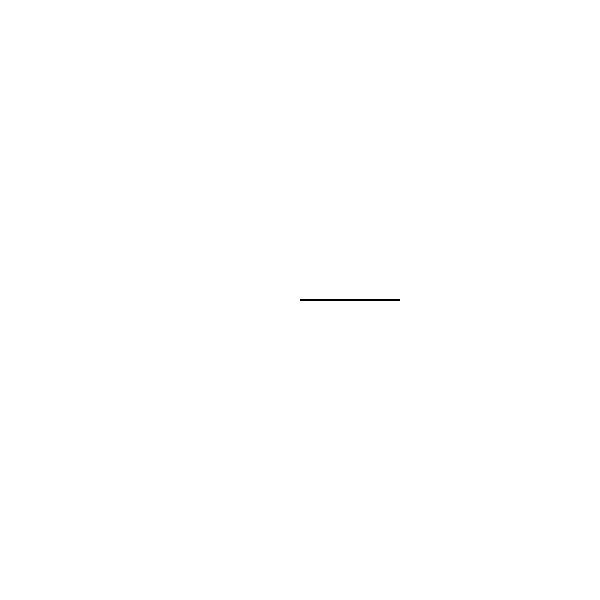

In [3]:
@svg begin
    forward(t, 100)
end

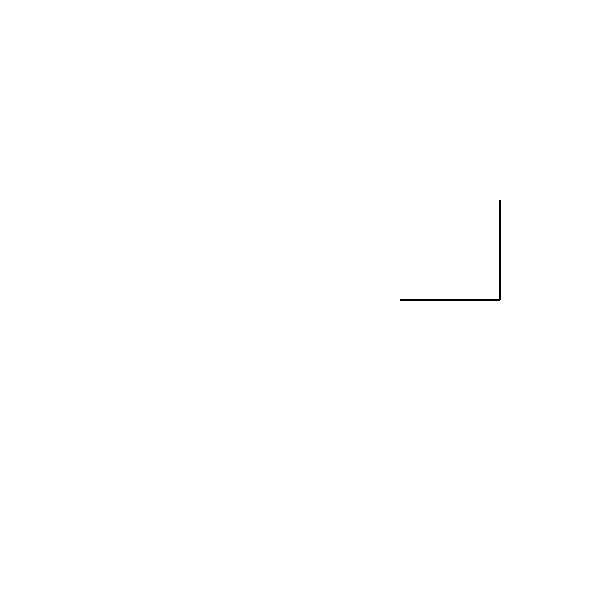

In [4]:
@svg begin
    forward(t, 100)
    turn(t, -90)
    forward(t, 100)
end

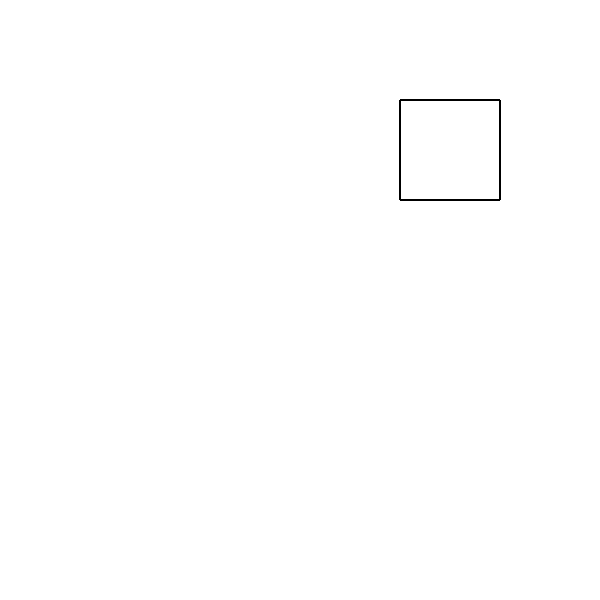

In [5]:
@svg begin
    for i in 1:4
        forward(t, 100)
        turn(t, -90)
    end
end

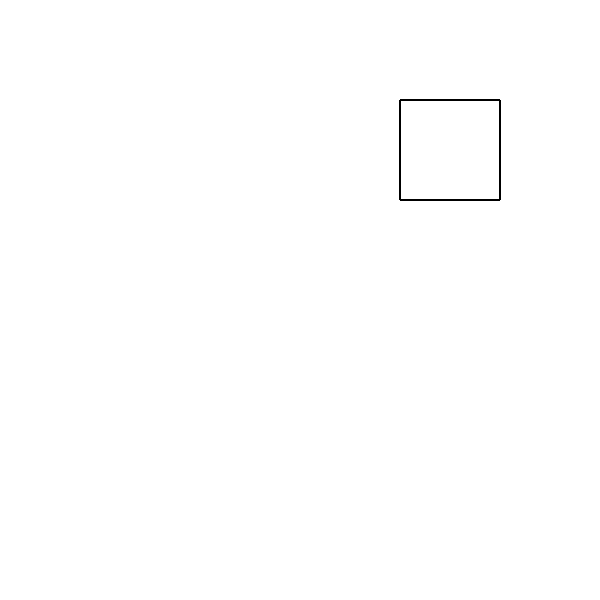

In [6]:
function square(t)
    for i in 1:4
        forward(t, 100)
        turn(t, -90)
    end
end

@svg begin
    square(t)
end

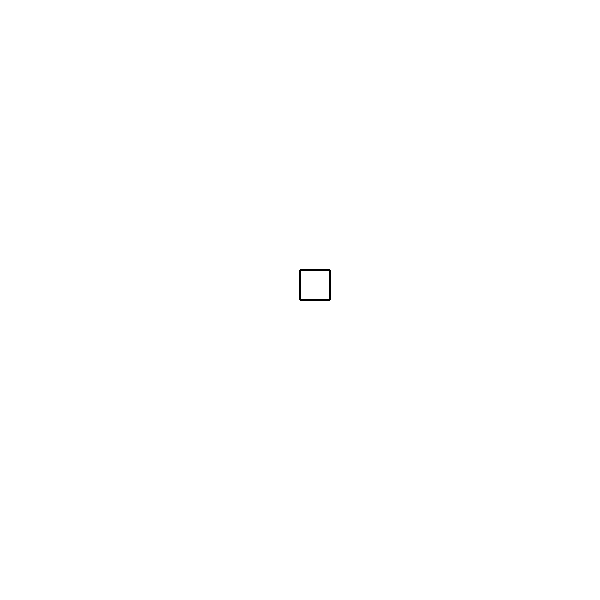

In [3]:
function square(t, len)
    for i in 1:4
        forward(t, len)
        turn(t, -90)
    end
end

@svg begin
    square(t, 30)
end

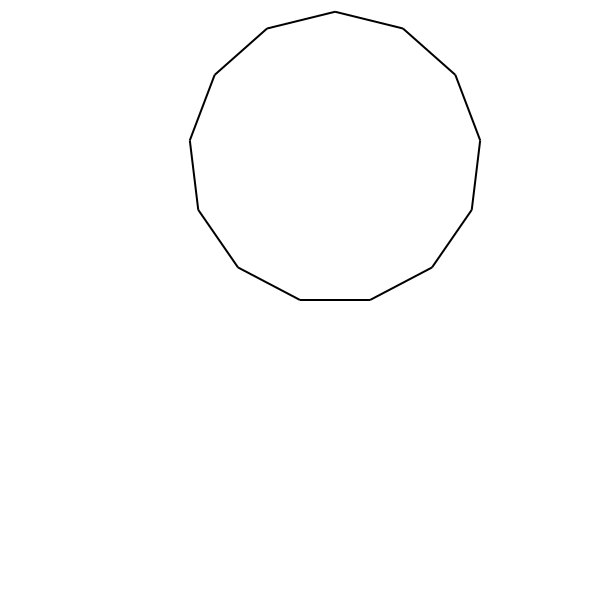

In [6]:
function poly(t, n, len)
    angle = 360 / n
    for i in 1:n
        forward(t, len)
        turn(t, -angle)
    end
end

@svg begin
    poly(t, 13, 70)
end

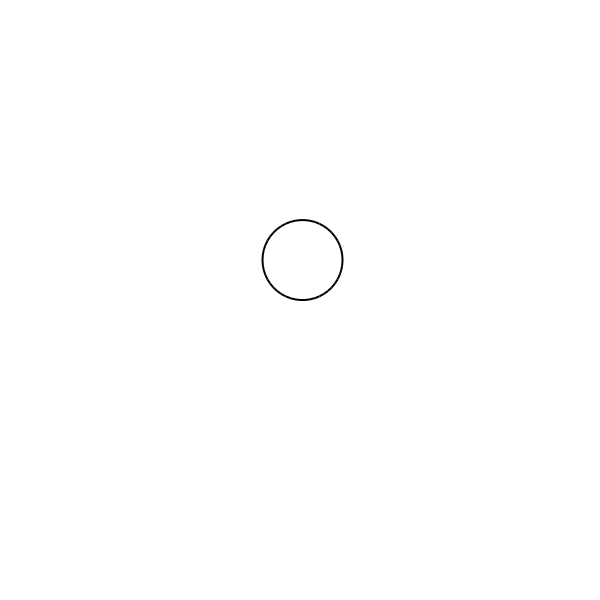

In [8]:
function circle(t, r)
    circumf = 2 * π * r
    n = 50
    len = circumf / n
    poly(t, n, len)
end

@svg begin
    circle(t, 40)
end

In [3]:
function circle(t, r)
    circumf = 2 * π * r
    n = trunc(circumf / 3) + 3 # must have ≥ 3 sides
    len = circumf / n
    poly(t, n, len)
end

circle (generic function with 1 method)

In [4]:
function arc(t, r, angle)
    arc_len = 2 * π * r * angle/360
    n = trunc(arc_len / 3) + 1
    step_len = arc_len / n
    step_angle = angle / n
    for i in 1:n
        forward(t, step_len)
        turn(t, -step_angle)
    end
end

arc (generic function with 1 method)

In [3]:
"""
polyline(t, n, len, angle)

Draws n line segments with the given length and
angle (in degrees) between them.  t is a turtle.
"""
function polyline(t, n, len, angle)
    for i in 1:n
        forward(t, len)
        turn(t, -angle)
    end
end

polyline (generic function with 1 method)

In [4]:
function polygon(t, n, len)
    angle = 360 / n
    polyline(t, n, len, angle)
end

function arc(t, r, angle)
    arc_len = 2 * π * r * angle/360
    n = trunc(arc_len / 3) + 1
    step_len = arc_len / 3
    step_angle = angle / n
    polyline(t, n, step_len, step_angle)
end
    

arc (generic function with 1 method)

In [5]:
function circle(t, r)
    arc(t, r, 360)
end

circle (generic function with 1 method)

In [6]:
"""
arc(t, r, angle)

Draws an arc with the given radius and angle:
    t: turtle
    r: radius
    angle: angle subtended by the arc, in degrees
"""
function arc(t, r, angle)
    arc_len = 2 * π * r * abs(angle) / 360
    n = trunc(arc_len / 4) + 3
    step_len = arc_len / n
    step_angle = angle / n

    # making a slight left turn before starting reduces
    # the error caused by the linear approximation of the arc
    turn(t, -step_angle/2)
    polyline(t, n, step_len, step_angle)
    turn(t, step_angle/2)
end

arc